<a href="https://colab.research.google.com/github/mahmudul2220/DMML/blob/main/colon%20new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import cv2
import matplotlib.pyplot as plt
import os
import numpy as np
import random

In [16]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import shutil

# Unmount drive if it was previously mounted and causing issues
if os.path.exists('/content/drive'):
    try:
        # shutil.rmtree is a powerful command; use with caution
        # It deletes the directory and all its contents.
        # This is safe to do for /content/drive if you're trying to remount
        # because /content/drive is usually empty before mounting.
        shutil.rmtree('/content/drive')
        print("Removed existing /content/drive directory.")
    except OSError as e:
        print(f"Error removing /content/drive: {e}. It might be in use or not exist.")

# Now, remount your drive
print("Attempting to mount Google Drive...")
from google.colab import drive
drive.mount('/content/drive')

Removed existing /content/drive directory.
Attempting to mount Google Drive...
Mounted at /content/drive


After running the above cell, please re-run the `drive.mount` cell (`ze2SYVHhBHmi`) to ensure your Google Drive is successfully mounted. Once mounted, you can proceed to re-run the data loading and preprocessing cells, starting with `a6IrDcQtHPF_`.

In [8]:
import os

dataset_path = "/content/drive/MyDrive/colon/"
print(os.listdir(dataset_path))

['models']


In [5]:
import os

base = "/content/drive/MyDrive/colon/"

for folder in os.listdir(base):
    path = os.path.join(base, folder)
    if os.path.isdir(path):
        print(folder, "→", len(os.listdir(path)))

processed → 6
models → 3
With colon cancer → 5000
without colon cancer → 5000


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, ResNet50, VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
import os
from PIL import Image

In [7]:
IMG_SIZE = 224
BATCH_SIZE = 16

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.30,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [9]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 21000 images belonging to 4 classes.


In [10]:
valid_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

Found 9000 images belonging to 4 classes.


In [11]:
test_generator = test_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
train_generator.class_indices

Found 30000 images belonging to 4 classes.


{'With colon cancer': 0,
 'models': 1,
 'processed': 2,
 'without colon cancer': 3}

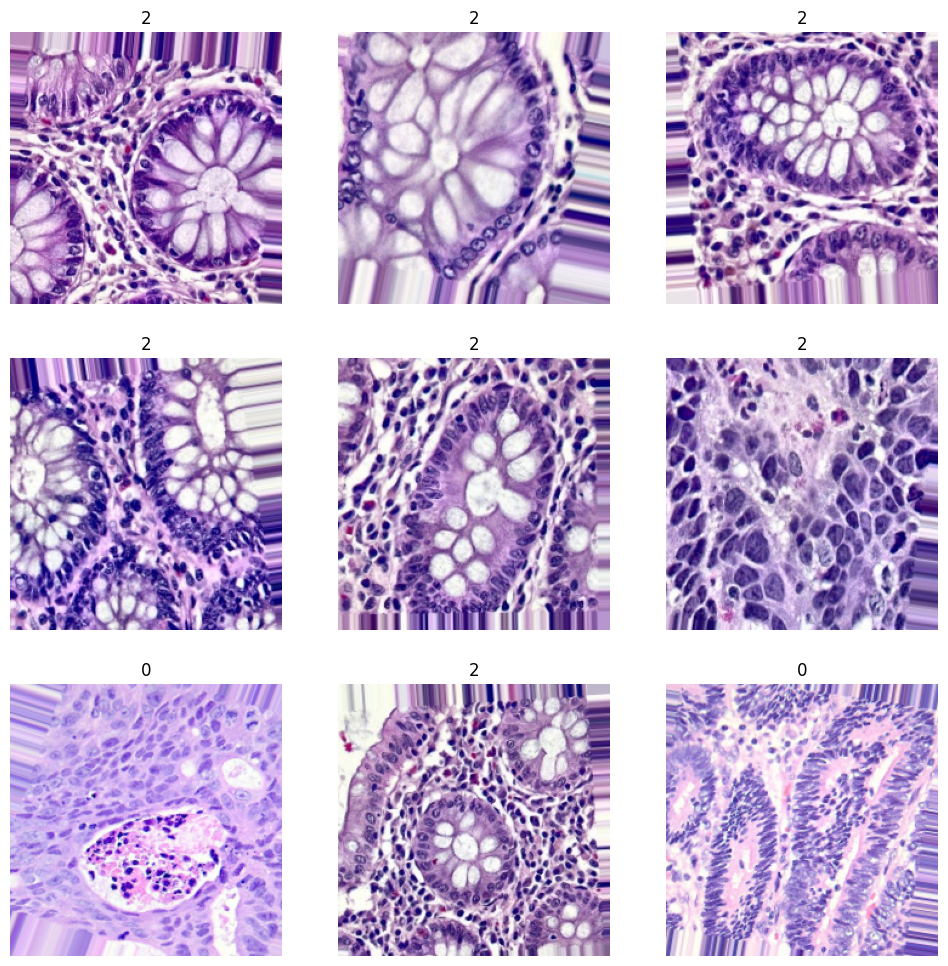

In [12]:
x, y = next(train_generator)
plt.figure(figsize=(12, 12))

for i in range(9):

    plt.subplot(3, 3, i + 1)
    plt.imshow(x[i])
    plt.title(np.argmax(y[i]))
    plt.axis("off")

plt.show()

In [13]:
processed_dir = "/content/drive/MyDrive/colon/processed/"
os.makedirs(processed_dir, exist_ok=True)

In [16]:
def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    lab = cv2.merge((l,a,b))
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return img

# Define the actual image data folders to process
image_categories = ['With colon cancer', 'without colon cancer']

# Define common image extensions
image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff', '.webp')

for cls in image_categories:
    cls_path = os.path.join(dataset_path, cls)
    if os.path.isdir(cls_path):
        save_cls_path = os.path.join(processed_dir, cls)
        os.makedirs(save_cls_path, exist_ok=True)

        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)

            # Check if the entry is a file and has a valid image extension
            if not os.path.isfile(img_path):
                print(f"Skipping non-file entry: {img_path}")
                continue
            if not img_name.lower().endswith(image_extensions):
                print(f"Skipping non-image file: {img_name}")
                continue

            try:
                # Read image
                img = cv2.imread(img_path)

                # Check if image was loaded successfully and is not empty
                if img is None or img.size == 0:
                    print(f"Warning: Could not read image or image is empty: {img_path}. Skipping.")
                    continue

                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                # CLAHE
                img = apply_clahe(img)

                # Resize
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                save_path = os.path.join(save_cls_path, img_name)
                cv2.imwrite(save_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

            except Exception as e:
                print("Error processing image:", img_path, e)

In [24]:
classes = ['With colon cancer', 'without colon cancer']
original_base = "/content/drive/MyDrive/colon/"
processed_base = "/content/drive/MyDrive/colon/processed/"

num_images = 2

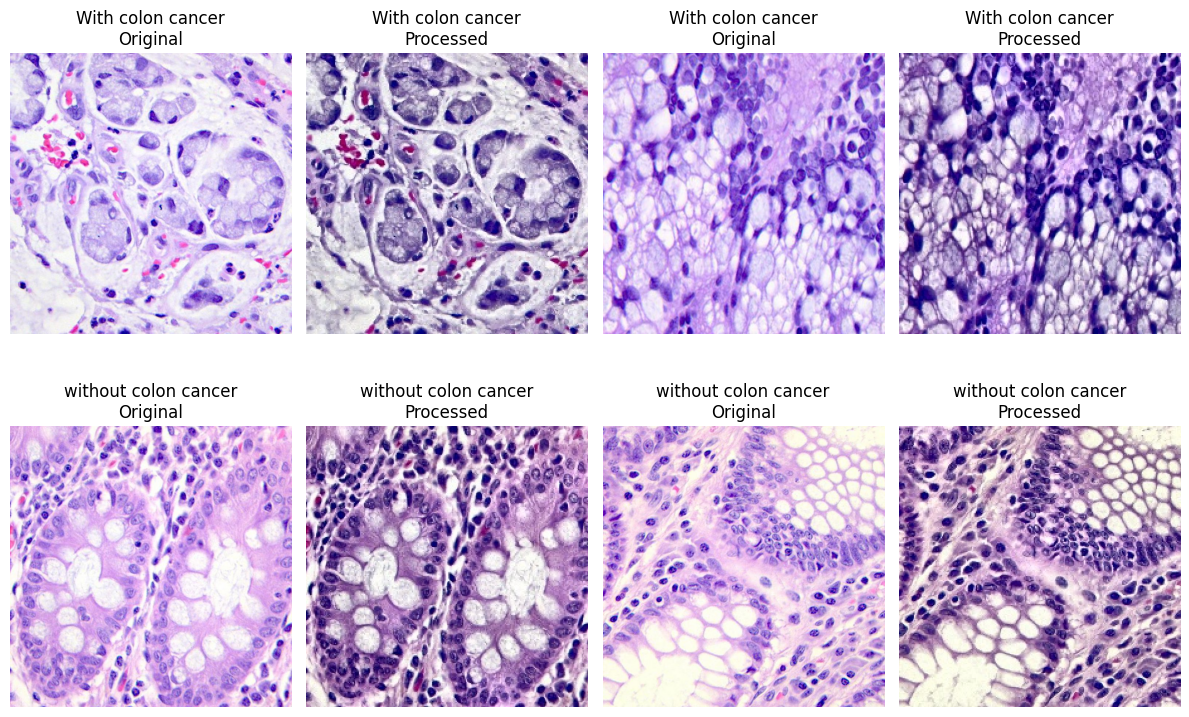

In [25]:
plt.figure(figsize=(12, len(classes)*4))

for idx, cls in enumerate(classes):
    orig_dir = os.path.join(original_base, cls)
    proc_dir = os.path.join(processed_base, cls)

    all_images = os.listdir(orig_dir)
    selected_images = random.sample(all_images, num_images)

    for i, img_name in enumerate(selected_images):
        img_orig = cv2.imread(os.path.join(orig_dir, img_name))
        img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)

        img_proc = cv2.imread(os.path.join(proc_dir, img_name))
        img_proc = cv2.cvtColor(img_proc, cv2.COLOR_BGR2RGB)

        plt.subplot(len(classes), num_images*2, idx*num_images*2 + i*2 + 1)
        plt.imshow(img_orig)
        plt.title(f"{cls}\nOriginal")
        plt.axis("off")

        plt.subplot(len(classes), num_images*2, idx*num_images*2 + i*2 + 2)
        plt.imshow(img_proc)
        plt.title(f"{cls}\nProcessed")
        plt.axis("off")

plt.tight_layout()
plt.show()

CNN Base Model (Beginner Friendly)

In [10]:
import shutil
import os
import time

# 1. Define Source (Drive) and Destination (Local Colab)
drive_source = "/content/drive/MyDrive/colon/processed/"
local_dest = "/content/local_colon_data/"

print(f"Copying data from {drive_source} to {local_dest}...")
start_time = time.time()

# 2. Check if already copied to avoid repeating (and errors)
if not os.path.exists(local_dest):
    try:
        shutil.copytree(drive_source, local_dest)
        print(f"✅ Copy complete! Time taken: {time.time() - start_time:.2f} seconds")
    except Exception as e:
        print(f"Error copying data: {e}")
else:
    print("✅ Data already exists locally. Skipping copy.")

# 3. Verify the files are there
if os.path.exists(local_dest):
    print(f"Classes found locally: {os.listdir(local_dest)}")

Copying data from /content/drive/MyDrive/colon/processed/ to /content/local_colon_data/...
Error copying data: [Errno 2] No such file or directory: '/content/drive/MyDrive/colon/processed/'


In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 2. Define Paths and Parameters
processed_base = "/content/drive/MyDrive/colon/processed/"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10  # Adjust based on your needs

# 3. Data Augmentation & Generators
# We use a validation split of 20% for training/validation
datagen = ImageDataGenerator(
    rescale=1./255,             # Normalize pixel values
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2        # 20% data for validation
)

print(f"Loading data from: {processed_base}")

train_generator = datagen.flow_from_directory(
    processed_base,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',   # Use 'binary' if only 2 classes
    subset='training'
)

val_generator = datagen.flow_from_directory(
    processed_base,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Loading data from: /content/drive/MyDrive/colon/processed/
Found 16000 images belonging to 6 classes.
Found 4000 images belonging to 6 classes.


In [18]:
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetB0, ResNet50, VGG16

def build_model(model_name, num_classes):
    """
    Builds a model based on the requested architecture name.
    """
    inputs = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)) # Use IMG_SIZE from previously defined
    base_model = None

    if model_name == 'EfficientNetB0':
        base_model = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=inputs)

    elif model_name == 'ResNet50':
        base_model = ResNet50(include_top=False, weights='imagenet', input_tensor=inputs)

    elif model_name == 'VGG16':
        base_model = VGG16(include_top=False, weights='imagenet', input_tensor=inputs)
    else:
        raise ValueError(f"Model {model_name} not supported.")

    # Freeze the base model layers (Transfer Learning)
    base_model.trainable = False

    # Add custom head for classification
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.2)(x)  # Dropout to prevent overfitting
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

In [1]:
import os
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# 1. Create a folder in your Drive to store the models
save_dir = "/content/drive/MyDrive/colon/models/"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"Created folder: {save_dir}")

model_names = ['EfficientNetB0', 'ResNet50', 'VGG16']
results = {}
num_classes = train_generator.num_classes

for name in model_names:
    print(f"\n{'='*40}")
    print(f"TRAINING MODEL: {name}")
    print(f"{'='*40}")

    # Build Model
    model = build_model(name, num_classes)

    # --- SAVING CONFIGURATION ---
    # Define where to save this specific model
    # e.g., /content/drive/MyDrive/colon/models/ResNet50_best.keras
    filepath = os.path.join(save_dir, f"{name}_best.keras")

    # Checkpoint: Save only if validation accuracy improves
    checkpoint = ModelCheckpoint(
        filepath,
        monitor='val_accuracy',
        verbose=1,
        save_best_only=True,
        mode='max'
    )

    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    # Train
    history = model.fit(
        train_generator,
        epochs=EPOCHS,
        validation_data=val_generator,
        callbacks=[early_stop, checkpoint], # Add checkpoint here
        verbose=1
    )

    results[name] = max(history.history['val_accuracy'])
    print(f"✅ Model saved to: {filepath}")

Created folder: /content/drive/MyDrive/colon/models/


NameError: name 'train_generator' is not defined

In [ ]:
names = list(results.keys())
values = list(results.values())

plt.figure(figsize=(10, 6))
plt.bar(names, values, color=['#4285F4', '#DB4437', '#F4B400'])
plt.ylabel('Validation Accuracy')
plt.title('Model Accuracy Comparison on Histopathology Data')
plt.ylim(0, 1.0)

for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.2%}", ha='center', fontweight='bold')

plt.show()

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

def build_custom_cnn(input_shape, num_classes):
    model = Sequential()

    # --- Block 1 ---
    # We start with 32 filters to capture low-level features (edges, textures)
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape))
    model.add(BatchNormalization()) # Normalizes inputs to speed up training
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.2)) # Randomly turns off 20% of neurons to prevent memorization

    # --- Block 2 ---
    # Increasing filters to 64 to capture more complex patterns
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.2))

    # --- Block 3 ---
    # Increasing to 128 filters
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.3)) # Slightly higher dropout deeper in the network

    # --- Block 4 ---
    # Deepest conv layer with 256 filters
    model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.3))

    # --- Classification Head ---
    model.add(Flatten()) # Flattens 2D maps to 1D vector

    # Dense layer for high-level reasoning
    model.add(Dense(512, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5)) # High dropout (50%) in the dense layer is standard

    # Output layer
    model.add(Dense(num_classes, activation='softmax'))

    # Compile
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

# --- Instantiate and Train ---

# 1. Build the model
custom_model = build_custom_cnn(
    input_shape=(224, 224, 3),
    num_classes=train_generator.num_classes
)

# 2. View the architecture summary
custom_model.summary()

# 3. Train the model
print(f"\nTraining Custom CNN for {EPOCHS} epochs...")

history_custom = custom_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    verbose=1
)

# 4. Show final result
final_acc = max(history_custom.history['val_accuracy'])
print(f"\n>>> Custom CNN Best Validation Accuracy: {final_acc:.2%}")

NameError: name 'train_generator' is not defined